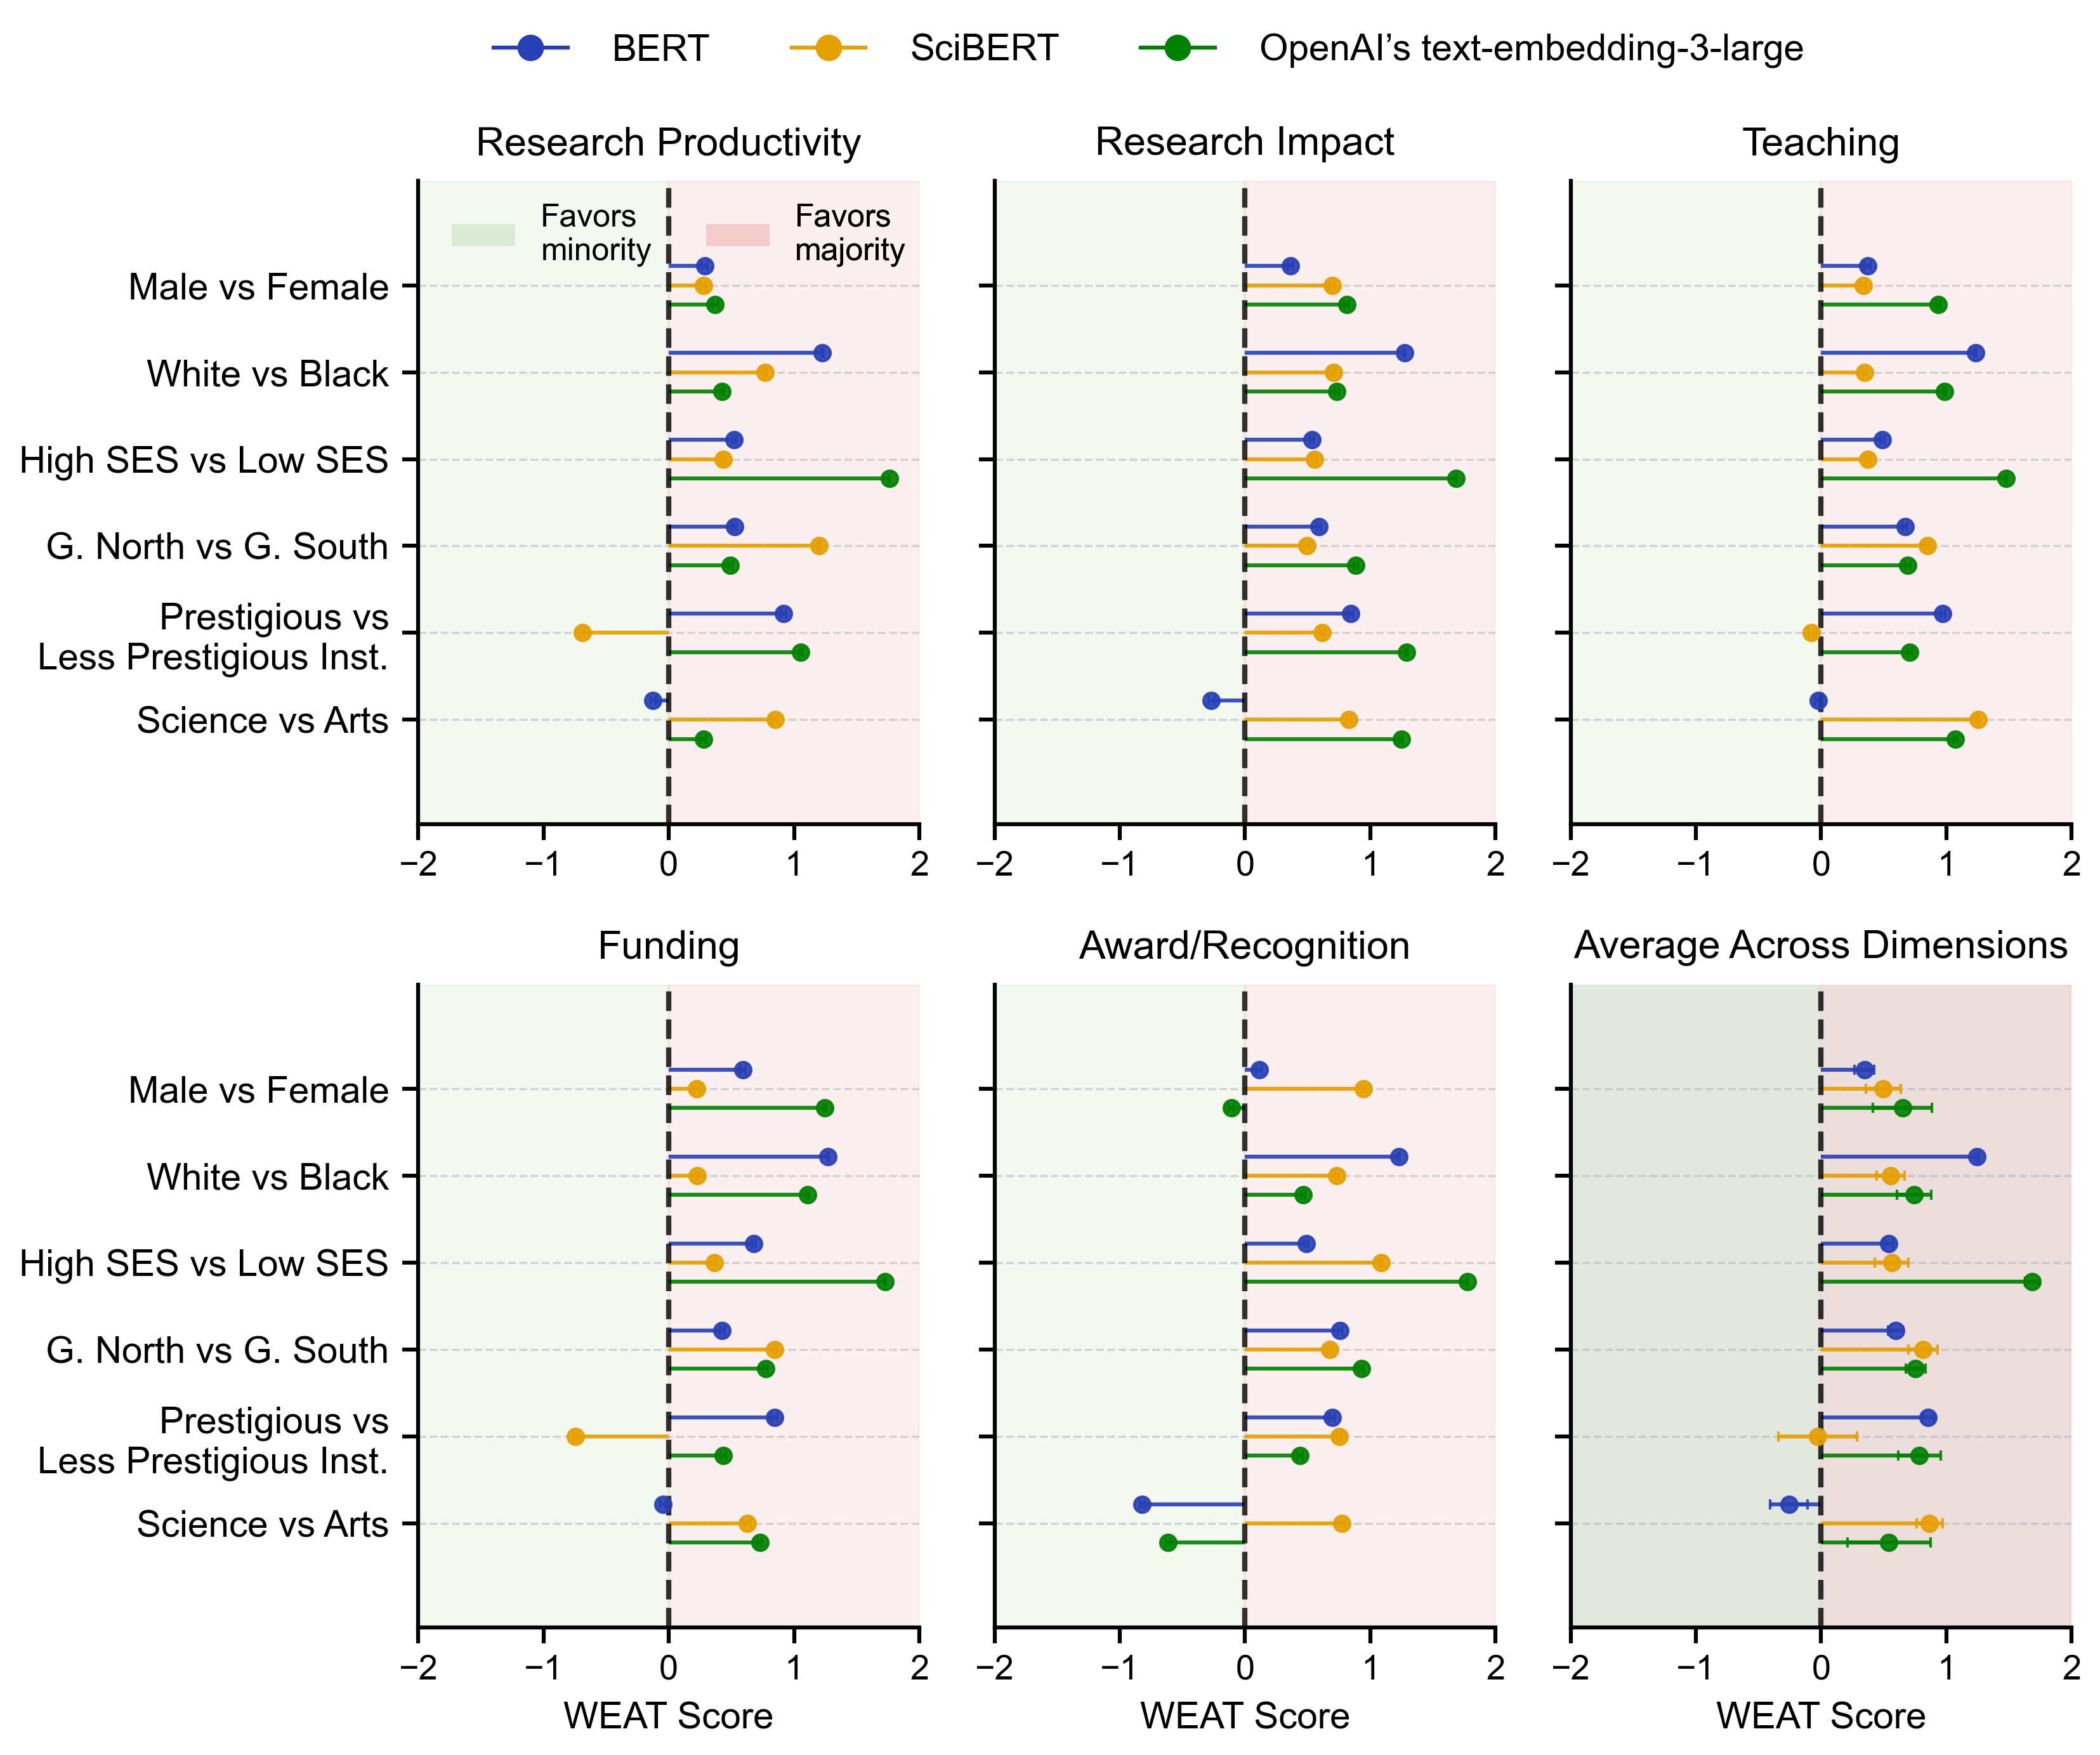

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.patches import Patch
import matplotlib.lines as mlines


# =========================
# GLOBAL STYLE CONFIGURATION
# =========================
plt.rcParams.update({
    # ---- Font sizes for Nature Human Behaviour ----
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 12,            # general figure text
    "axes.labelsize": 14,       # axis labels
    "axes.titlesize": 15,       # panel titles
    "legend.fontsize": 14,      # legend text
    "xtick.labelsize": 13,
    "ytick.labelsize": 14,

    # ---- Line settings ----
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,

    # ---- Figure size (Nature double-column max width = 7.1 in) ----
    "figure.figsize": (10.1, 9.5),     # << THIS is the most important change
    "figure.dpi": 300,

    # ---- Saving ----
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


# =========================
# LABEL AND ORDER MAPPINGS
# =========================
desired_order = [
    "Male vs Female",
    "White vs Black",
    "High SES vs Low SES",
    "G_North vs G_South",
    "P_Inst vs NP_Inst",
    "Science vs Arts",
]

index_mapping = {
    "Location": "G_North vs G_South",
    "Socioeconomis_bias": "High SES vs Low SES",
    "EU vs AA": "White vs Black",
}

# Mapping for xtick labels (pretty labels)
xtick_replacements = {
    "G_North vs G_South": "G. North vs G. South",
    "P_Inst vs NP_Inst": "Prestigious vs\nLess Prestigious Inst.",
}

# =========================
# LOAD AND PREPARE DATA
# =========================
def load_and_reorder(path):
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.map(lambda x: index_mapping.get(x, x))
    df = df.loc[desired_order]
    return df

df_research = load_and_reorder("General Research vs Failure.csv")
df_teaching = load_and_reorder("Teaching effectiveness vs Failure.csv")
df_funding = load_and_reorder("Funding sucess vs Failure.csv")
df_award = load_and_reorder("Award and Recognition vs Failure.csv")
df_productivity = load_and_reorder("Research Productivity vs Failure.csv")

dataframes = [df_productivity, df_research, df_teaching, df_funding, df_award]
titles = [
    "Research Productivity",
    "Research Impact",
    "Teaching",
    "Funding",
    "Award/Recognition",
]

# =========================
# PLOT PANEL FUNCTION
# =========================
def plot_panel_on_ax(ax: Axes, df: pd.DataFrame, title: str,
                     show_ylabel: bool, show_xlabel: bool,
                     xtick_replacements: dict,
                     is_average: bool=False) -> None:
    """Render a single WEAT panel onto the provided Axes."""

    # ---- Define models and styles ----
    models = ["BERT", "SciBERT", "OpenAI"]
    display_names = ["BERT", "SciBERT", "OpenAI’s text-embedding-3-large"]
    # colors = ["#0072B2", "#E69F00", "#009E73"]
    # colors = ['blue', 'orange', 'green']
    colors = ["#2840B6", '#E69F00', 'green']

    offsets = [-0.22, 0.0, 0.22]
    #offsets = [-0.18, 0, 0.18]


    # ---- Background shading ----
    ax.axvspan(-2.0, 0.0, color="#D9EAD3", alpha=0.3, zorder=0)
    ax.axvspan(0.0, 2.0, color="#F4CCCC", alpha=0.3, zorder=0) #"#D9EAD3", 0.25
    # ---- Light gray background for average panel ----
    if is_average:
        #ax.set_facecolor("#E6E6E6")  # slightly darker gray
        ax.set_facecolor("#E8E6E3")


    # ---- Apply pretty tick replacements ----
    y_labels_raw = list(df.index)
    y_labels = [xtick_replacements.get(lbl, lbl) for lbl in y_labels_raw]
    y_pos = np.arange(len(y_labels))

    # ---- Plot means ± SE ----
    for model, label, color, offset in zip(models, display_names, colors, offsets):
        means = df[f"WEAT Score {model}"].values
        errs = df[f"SE {model}"].values

        # Horizontal connectors from 0 to mean
        for y, mean in zip(y_pos, means):
            xa, xb = (0.0, mean) if mean >= 0 else (mean, 0.0)
            ax.hlines(y + offset, xa, xb, color=color, linewidth=1.5, alpha=0.9)

        # Dots with error bars
        ax.errorbar(
            means,
            y_pos + offset,
            xerr=errs,
            fmt="o",
            ms=6,
            lw=1.5,
            capsize=2,
            color=color,
            label=label,
            alpha=0.9,
        )

    # ---- Axes configuration ----
    ax.axvline(0, color="black", linestyle="--", lw=2.0, alpha=0.8)
    ax.set_xlim(-2.0, 2.0)
    ax.set_xticks([-2.0,-1.0, 0.0, 1.0, 2.0])
    ax.tick_params(axis="x", pad=4, width=3)
    ax.tick_params(axis="y", pad=5, width=3)
    ax.tick_params(axis="both", width=1.5, length=6)

    # ---- Labels ----
    if show_xlabel:
        ax.set_xlabel("WEAT Score", labelpad=6)
    else:
        ax.set_xlabel("")

    if show_ylabel:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels)
        ax.invert_yaxis()
    else:
        ax.tick_params(axis="y", labelleft=False)

    # ---- Title ----
    title_fontsize = plt.rcParams["axes.titlesize"]
    ax.set_title(title, fontsize=title_fontsize, fontweight="normal", pad=10) #fontweight="bold",  color="gray", 

    # ---- Grid & spines ----
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["bottom", "left"]:
        ax.spines[side].set_linewidth(1.5)
    ax.margins(y=0.18)


# =========================
# BUILD COMPLETE 6-PANEL FIGURE
# =========================
def build_weat_panels(dataframes, titles, xtick_replacements):
    """
    Build a 2x3 figure where the 6th column is
    the average WEAT score (pooled SE).
    """
    models = ["BERT", "SciBERT", "OpenAI"]
    # ---- Compute average WEAT scores & pooled SE ----
    df0 = dataframes[0]
    factors = df0.index
    mean_scores, mean_ses = [], []

    for factor in factors:
        model_means, model_ses = [], []
        for model in models:
            vals = np.array([df.loc[factor, f"WEAT Score {model}"] for df in dataframes], dtype=float)
            mean_val = np.nanmean(vals)
            se_val = np.nanstd(vals, ddof=1) / np.sqrt(np.sum(~np.isnan(vals)))  # correct SE of mean
            model_means.append(mean_val)
            model_ses.append(se_val)
        mean_scores.append(model_means)
        mean_ses.append(model_ses)


    avg_df = pd.DataFrame({
        "WEAT Score BERT": [m[0] for m in mean_scores],
        "SE BERT": [s[0] for s in mean_ses],
        "WEAT Score SciBERT": [m[1] for m in mean_scores],
        "SE SciBERT": [s[1] for s in mean_ses],
        "WEAT Score OpenAI": [m[2] for m in mean_scores],
        "SE OpenAI": [s[2] for s in mean_ses],
    }, index=factors)

    avg_title = "Average Across Dimensions"
    dataframes = dataframes + [avg_df]
    titles = titles + [avg_title]

    # ---- Create figure ----
    fig, axs = plt.subplots(2, 3, sharey="row", constrained_layout=False,
                            gridspec_kw={"wspace": 0.15, "hspace": 0.25})

    # ---- Plot each panel ----
    for i, (df, title) in enumerate(zip(dataframes, titles)):
        row, col = divmod(i, 3)
        ax = axs[row, col]
        show_ylabel = (col == 0)
        show_xlabel = (row == 1)
        is_average = (title == avg_title)
        plot_panel_on_ax(ax, df, title, show_ylabel, show_xlabel,
                         xtick_replacements, is_average=is_average)

    # # ---- Combined legend ----
    model_handles, model_labels = axs[0, 0].get_legend_handles_labels()

    model_colors = ["#2840B6", '#E69F00', 'green']   #['blue', 'orange', 'green']

    # Make a simple horizontal line with a round marker (no caps)
    clean_handles = [
        mlines.Line2D([0, 0.1], [0,0], color=c, marker='o', markersize=9,
                    linewidth=1.5, markerfacecolor=c, markeredgecolor=c)
        for c in model_colors
    ]

    # ✅ Build legend
    legend = fig.legend(
        clean_handles, model_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=5,
        fontsize=plt.rcParams["legend.fontsize"],
        frameon=False,
        handletextpad=1.2,
        columnspacing=2.2
    )

    # ================================
    # PLACE BACKGROUND LEGENDS IN FIRST AXIS
    # ================================
    first_ax = axs[0, 0]

    # Create dummy shading patches (legend handles)
    dummy_minority = Patch(facecolor="#D9EAD3", alpha=0.9, edgecolor="none", label="Favors\nminority")
    dummy_majority = Patch(facecolor="#F4CCCC", alpha=0.9, edgecolor="none", label="Favors\nmajority")

    # Left: negative side
    leg1 = first_ax.legend(
        handles=[dummy_minority],
        loc="upper left",
        bbox_to_anchor=(0.01, 1.01),
        frameon=False,
        fontsize=12
    )
    first_ax.add_artist(leg1)

    # Right: positive side
    leg2 = first_ax.legend(
        handles=[dummy_majority],
        loc="upper right",
        bbox_to_anchor=(1.03, 1.01),
        frameon=False,
        fontsize=12
    )
    first_ax.add_artist(leg2)

    # ---- Layout & save ----
    #plt.subplots_adjust(bottom=0.09, top=0.94, left=0.06, right=0.98, wspace=0.3, hspace=0.18)
    plt.subplots_adjust(bottom=0.12, top=0.92, left=0.12, right=0.98,
                    wspace=0.25, hspace=0.35)

    fig.savefig("figure2.png", dpi=plt.rcParams["figure.dpi"],
                bbox_inches="tight", transparent=False)
    plt.show()


# =========================
# EXECUTE
# =========================
build_weat_panels(dataframes, titles, xtick_replacements)


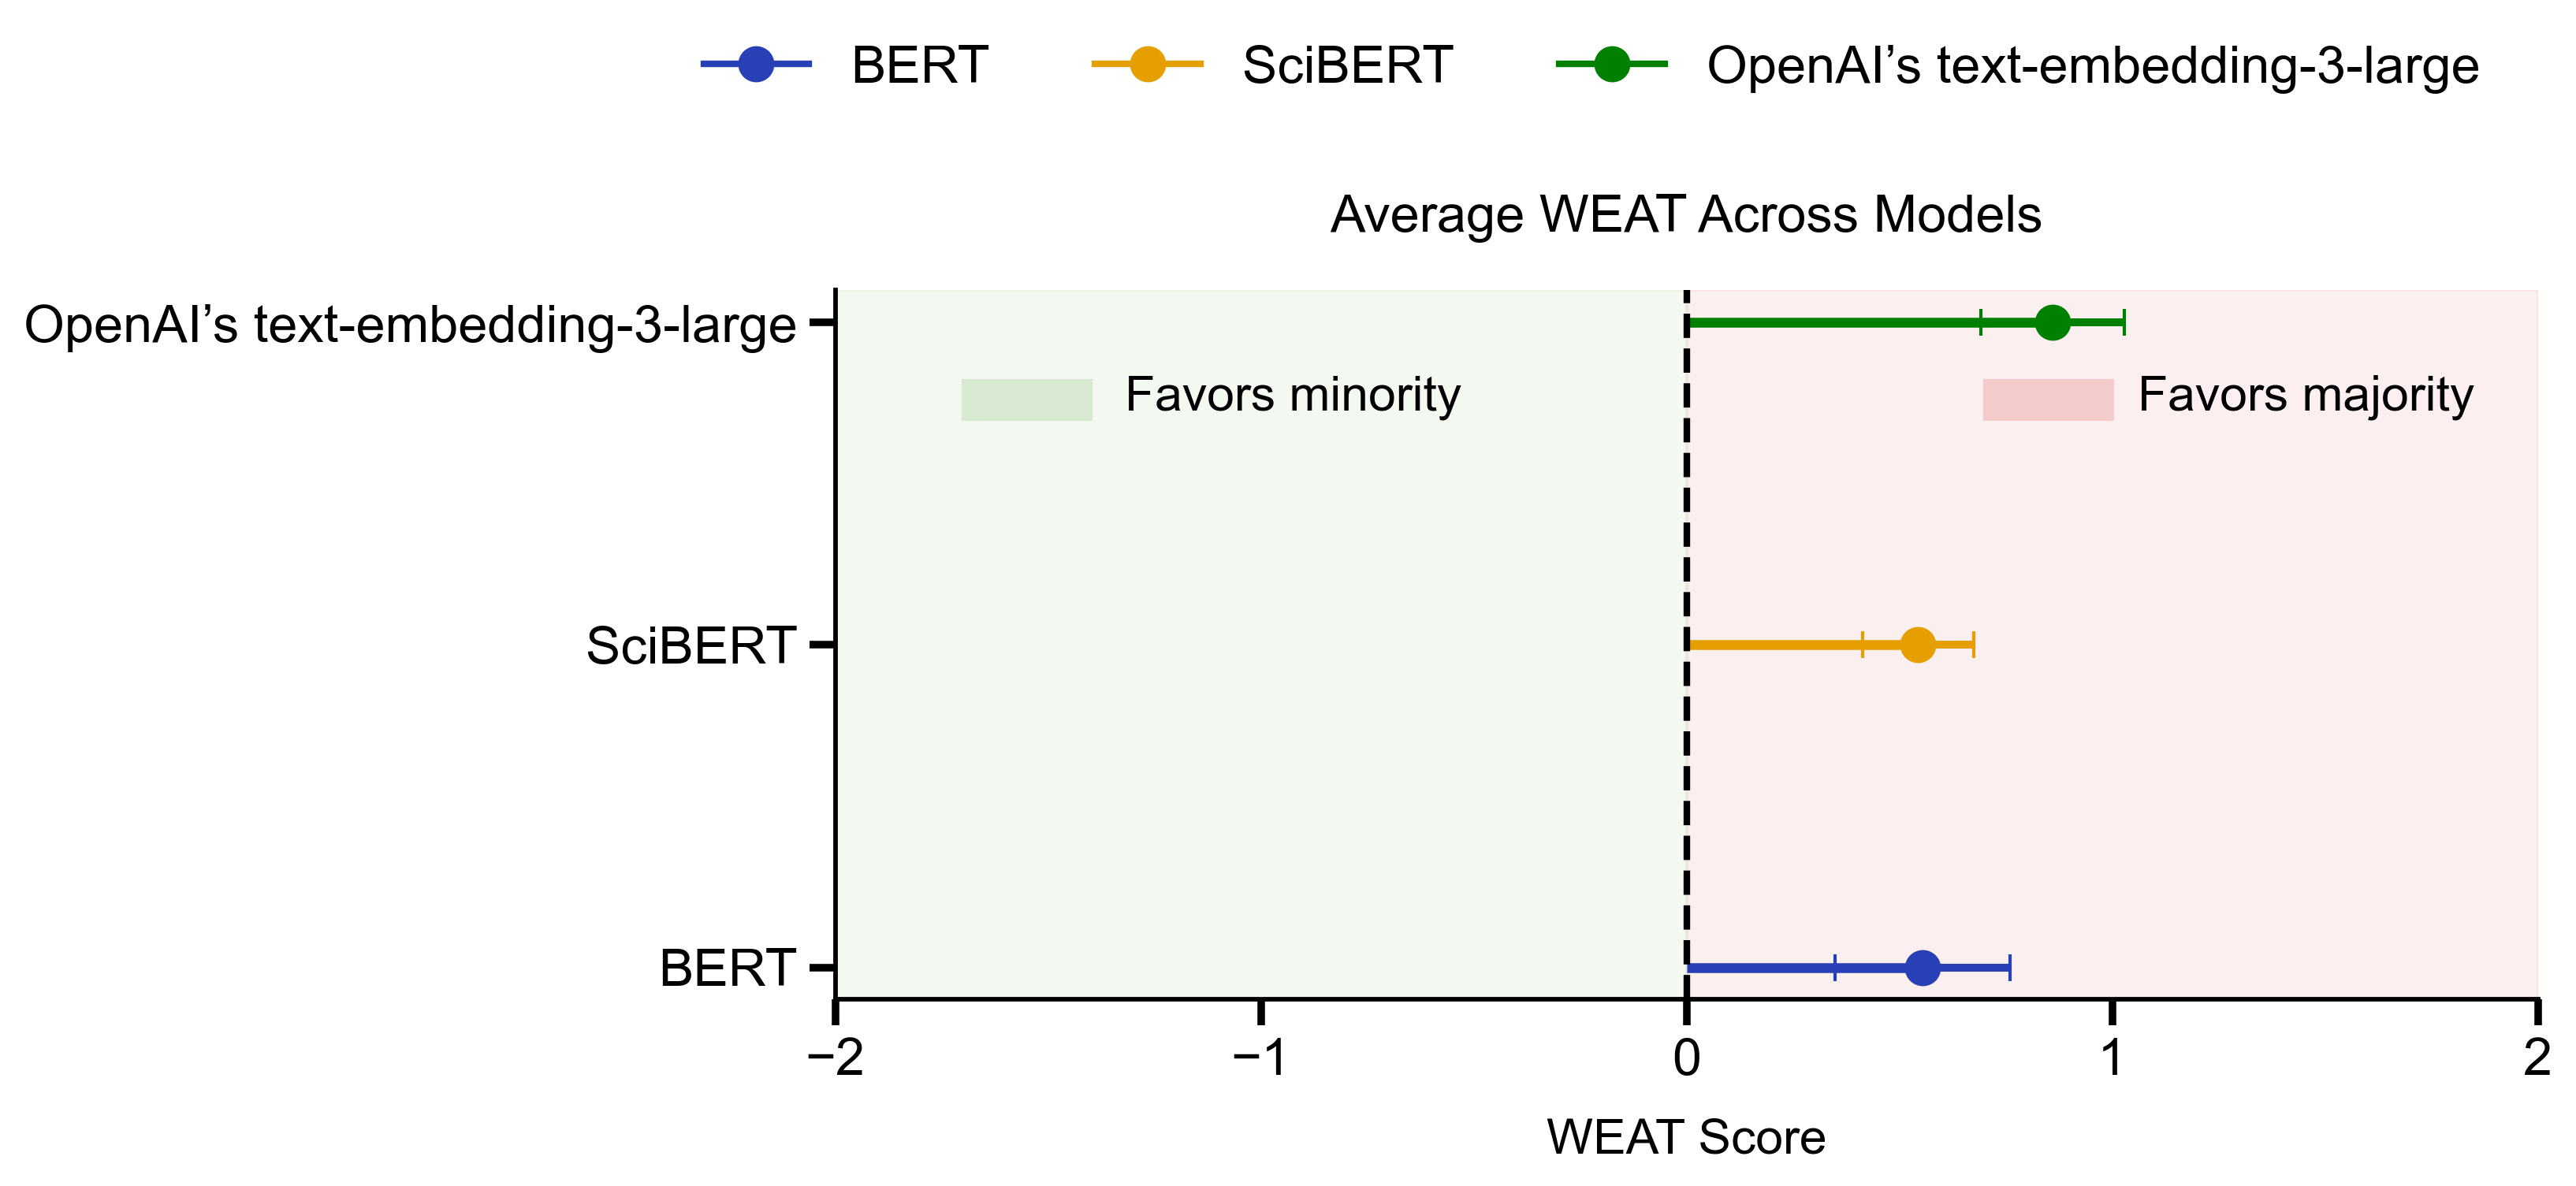

In [43]:
# ============================================================
# FIGURE — Overall Final Average WEAT Score (Horizontal Dot Plot)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# =========================
# NHB STYLING
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 16,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "figure.figsize": (10, 4.0),
    "figure.dpi": 300,
})

# =========================
# FILES TO LOAD (5 WEAT DIMENSIONS)
# =========================
paths = {
    "Research Productivity":        "Research Productivity vs Failure.csv",
    "General Research":             "General Research vs Failure.csv",
    "Teaching":                     "Teaching effectiveness vs Failure.csv",
    "Funding":                      "Funding sucess vs Failure.csv",
    "Awards":                       "Award and Recognition vs Failure.csv"
}

# ---- Define models and styles ----
models = ["BERT", "SciBERT", "OpenAI"]
display_names = ["BERT", "SciBERT", "OpenAI’s text-embedding-3-large"]
colors = ["#2840B6", "#E69F00", "green"]

# =========================
# LOAD ALL 5 DATASETS
# =========================
all_panels = [pd.read_csv(p, index_col=0) for p in paths.values()]

df0 = all_panels[0]
factors = df0.index

# =========================
# 1) AVERAGE ACROSS DIMENSIONS PER FACTOR
# =========================
avg_per_factor = pd.DataFrame(index=factors)

for model in models:
    mvals, ses = [], []
    for factor in factors:
        vals = np.array([df.loc[factor, f"WEAT Score {model}"] for df in all_panels])
        pooled = np.nanstd(vals, ddof=1) / np.sqrt(np.sum(~np.isnan(vals)))
        mvals.append(np.nanmean(vals))
        ses.append(pooled)

    avg_per_factor[f"WEAT {model}"] = mvals
    avg_per_factor[f"SE {model}"] = ses

# =========================
# 2) FINAL GLOBAL AVERAGE ACROSS FACTORS
# =========================
global_means = []
global_ses   = []

for model in models:
    vals = avg_per_factor[f"WEAT {model}"].values
    pooled = np.std(vals, ddof=1) / np.sqrt(len(vals))

    global_means.append(np.mean(vals))
    global_ses.append(pooled)

# =========================
# 3) BUILD HORIZONTAL DOT + CONNECTOR FIGURE
# =========================
fig, ax = plt.subplots()

y_pos = np.arange(len(models))

# Background shading (horizontal WEAT scale)
ax.axvspan(-2, 0, color="#D9EAD3", alpha=0.3, zorder=0)  # favors minority
ax.axvspan(0,  2, color="#F4CCCC", alpha=0.3, zorder=0)  # favors majority

# Plot connectors and markers
for i, (mean, se, color) in enumerate(zip(global_means, global_ses, colors)):
    # Connector line (0 → mean)
    xa, xb = (0, mean) if mean >= 0 else (mean, 0)
    ax.hlines(y_pos[i], xa, xb, color=color, lw=3)

    # Dot + horizontal error bars
    ax.errorbar(
        mean, y_pos[i],
        xerr=se,
        fmt="o",
        ms=10,
        lw=2.4,
        capsize=4,
        color=color
    )

# Axis formatting
ax.axvline(0, color="black", linestyle="--", linewidth=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(display_names)
ax.set_xlabel("WEAT Score", labelpad=10)
ax.set_title("Average WEAT Across Models", pad=18)

ax.set_xlim(-2.0, 2.0)
ax.set_xticks([-2, -1, 0, 1, 2])

ax.tick_params(axis="both", length=8, width=2.3, direction="out")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

# =========================
# Background Legend at TOP
# =========================
ax.text(-1.32, 0.63 + 1.1, "Favors minority", fontsize=15, ha="left")
ax.add_patch(Rectangle((-1.7, 1.7), 0.3, 0.12, color="#D9EAD3", alpha=1.0))

ax.text(1.06, 0.63 + 1.1, "Favors majority", fontsize=15, ha="left")
ax.add_patch(Rectangle((0.7, 1.7), 0.3, 0.12, color="#F4CCCC", alpha=1.0))

# =========================
# MODEL LEGEND
# =========================
handles = [
    Line2D([0,0.2],[0, 0], marker="o", color=c, markersize=10, lw=2, label=m)
    for c, m in zip(colors, display_names)
]

fig.legend(
    handles, display_names,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.17)
)

plt.subplots_adjust(top=0.86, left=0.18)
plt.show()
fig.savefig("figure2_mean.png", dpi=300, bbox_inches="tight")
